<a href="https://colab.research.google.com/github/singhaditi2710/python-assignment-part-4/blob/main/Part_4_Data_Visualization_%26_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import io

csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(csv_data))
df.to_csv("students.csv", index=False)
print("✓ students.csv created successfully.")

✓ students.csv created successfully.


In [3]:
# Task 1 — Data Exploration with Pandas

# 1. Load the dataset
df = pd.read_csv("students.csv")

# 2. Basic Inspection
print("--- First 5 Rows ---")
print(df.head())

print(f"\nShape of dataset: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)

# 3. Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe())

# 4. Pass/Fail Count
print("\n--- Pass/Fail Count ---")
print(df['passed'].value_counts())

# 5. Average score per subject for Passing vs Failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n--- Average Scores: Passing Students ---")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n--- Average Scores: Failing Students ---")
print(df[df['passed'] == 0][subject_cols].mean())

# 6. Student with highest overall average
# We compute a temporary column to find the winner
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_avg'].idxmax()]

print(f"\nStudent with highest overall average: {top_student['name']} ({top_student['temp_avg']:.2f})")

# Clean up temp column for now (Task 2 will add it formally)
df.drop(columns=['temp_avg'], inplace=True)

--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset: (15, 9)

--- Data Types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
          

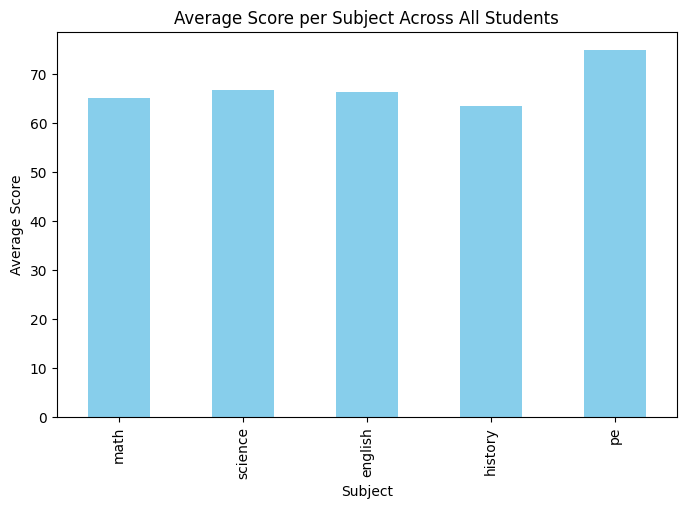

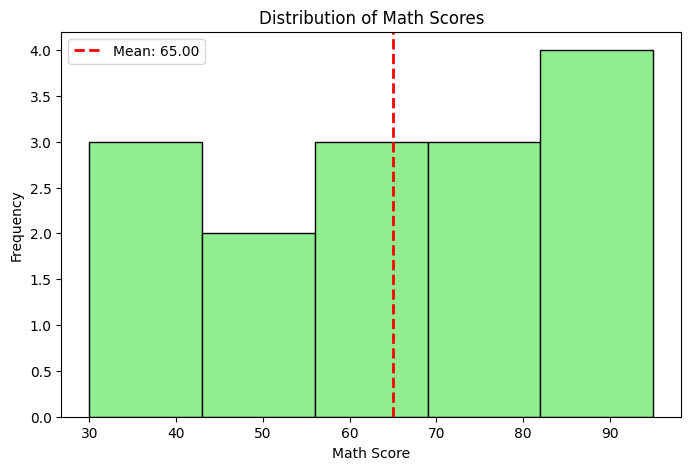

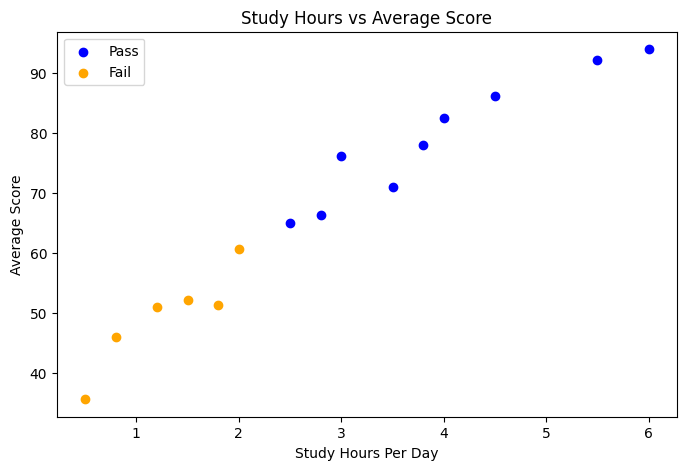

/tmp/ipykernel_4463/3235676588.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


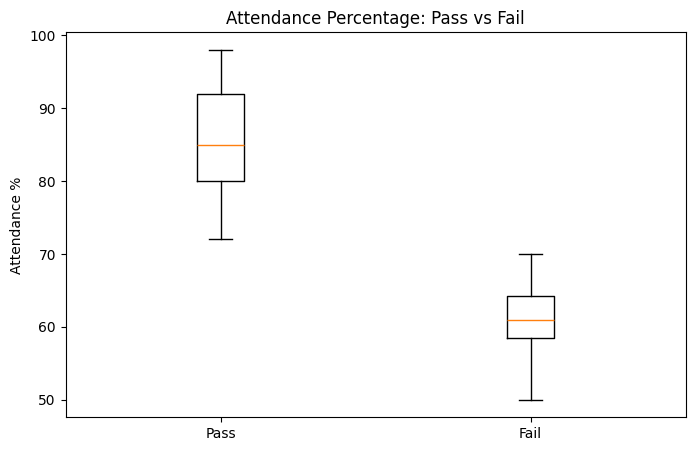

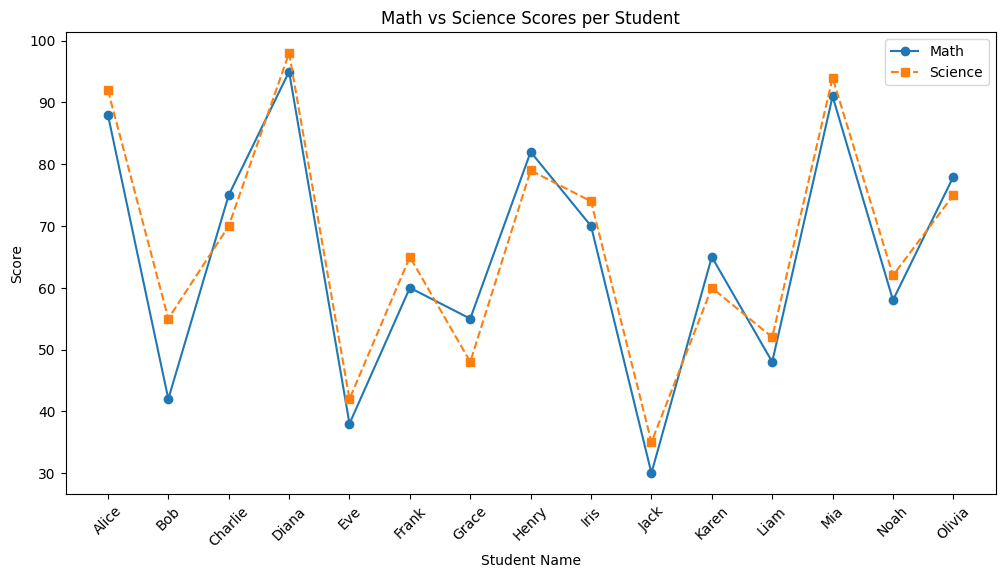

In [4]:
# Task 2 — Data Visualization with Matplotlib

import matplotlib.pyplot as plt

# Add the formal avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart - Avg Score Per Subject
plt.figure(figsize=(8, 5))
df[subject_cols].mean().plot(kind='bar', color='skyblue')
plt.title("Average Score per Subject Across All Students")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram - Math Scores Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(df['math'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['math'].mean():.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

# 3. Scatter Plot - Study Hours vs Avg Score
plt.figure(figsize=(8, 5))
pass_group = df[df['passed'] == 1]
fail_group = df[df['passed'] == 0]

plt.scatter(pass_group['study_hours_per_day'], pass_group['avg_score'], color='blue', label='Pass')
plt.scatter(fail_group['study_hours_per_day'], fail_group['avg_score'], color='orange', label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box Plot - Attendance (Pass vs Fail)
plt.figure(figsize=(8, 5))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance %")
plt.savefig("plot4_boxplot.png")
plt.show()

# 5. Line Plot - Math and Science Scores
plt.figure(figsize=(12, 6))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.xticks(rotation=45)
plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

/tmp/ipykernel_4463/2244165201.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Fail', 'Pass'])
/tmp/ipykernel_4463/2244165201.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Fail', 'Pass'])


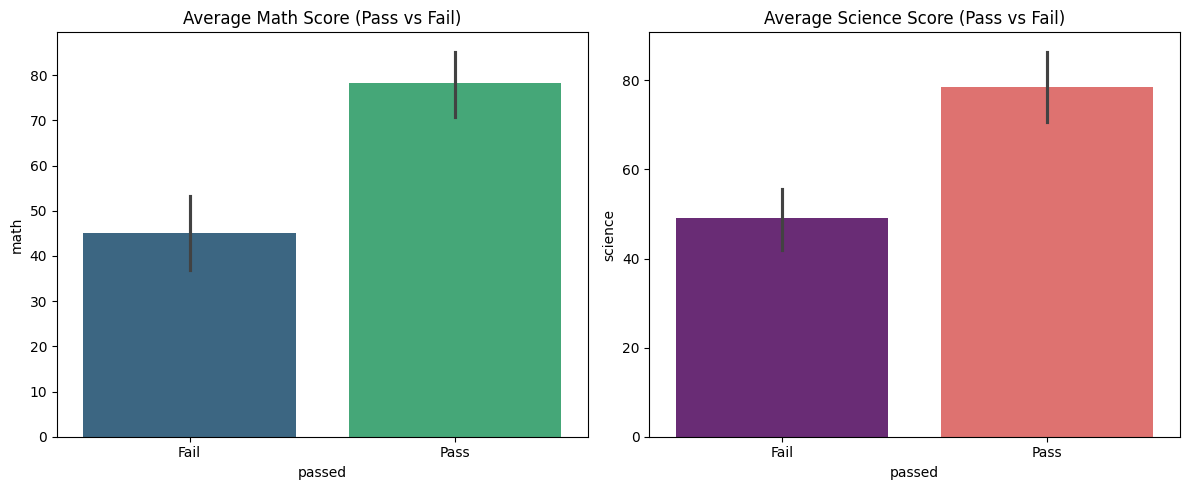

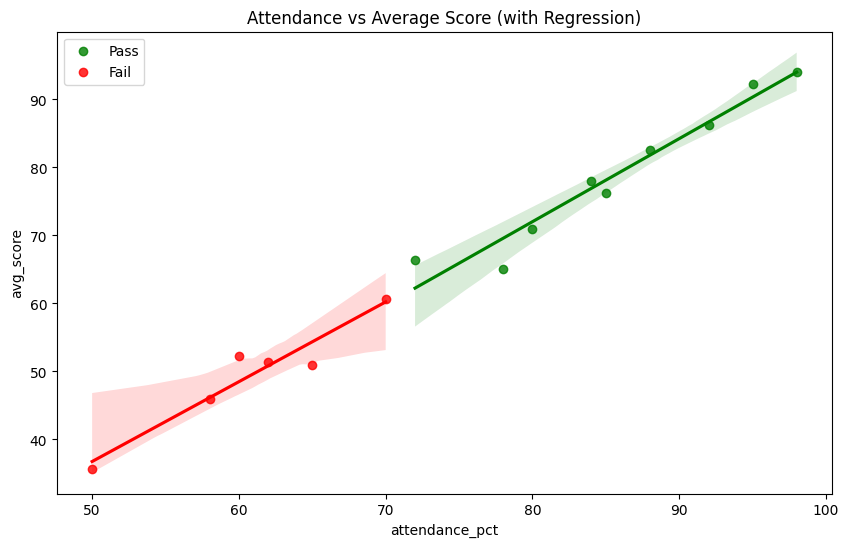

In [5]:
# Task 3 — Data Visualization with Seaborn

import seaborn as sns

# 1. Seaborn Bar Plot (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1, hue='passed', palette='viridis', legend=False)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xticklabels(['Fail', 'Pass'])

sns.barplot(data=df, x='passed', y='science', ax=ax2, hue='passed', palette='magma', legend=False)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# 2. Seaborn Scatter Plot with Regression
plt.figure(figsize=(10, 6))
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='green')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red')

plt.title("Attendance vs Average Score (with Regression)")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# --- Comparison Comment ---
# Seaborn is significantly easier for handling complex statistical visualizations like
# regression lines and splitting data by category without manual filtering. However,
# Matplotlib offers more granular control over individual plot elements like the
# specific placement of mean lines in histograms or custom boxplot labels.

Training Accuracy: 100.00%
Test Accuracy: 100.00%

--- Test Set Predictions ---
Student: Jack     | Actual: 0 | Predicted: 0 | ✅ correct
Student: Liam     | Actual: 0 | Predicted: 0 | ✅ correct
Student: Alice    | Actual: 1 | Predicted: 1 | ✅ correct

--- Feature Importance (Sorted) ---
english             : 0.8125
attendance_pct      : 0.5219
study_hours_per_day : 0.4844
pe                  : 0.4750
math                : 0.4379
science             : 0.3230
history             : 0.2629


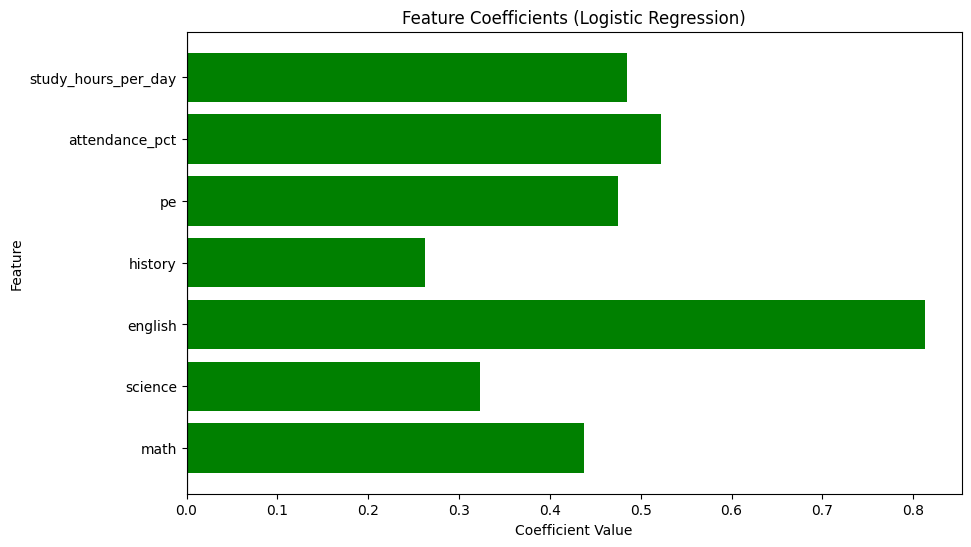


--- Prediction for New Student ---
Predicted Result: Pass
Probabilities (Fail vs Pass): [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [6]:
# Task 4 — Machine Learning with scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Step 1: Prepare Data
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 2: Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_acc * 100:.2f}%")

# Step 3: Evaluate Model
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Test Set Predictions ---")
test_names = df.loc[X_test.index, 'name'].values
for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ correct" if actual == pred else "❌ wrong"
    print(f"Student: {name:<8} | Actual: {actual} | Predicted: {pred} | {status}")

# Step 4: Feature Importance
coeffs = model.coef_[0]
feature_importance = sorted(zip(features, coeffs), key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Importance (Sorted) ---")
for feat, coef in feature_importance:
    print(f"{feat:<20}: {coef:.4f}")

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coeffs]
plt.barh(features, coeffs, color=colors)
plt.title("Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# Step 5: Bonus - Predict for a New Student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"
print(f"\n--- Prediction for New Student ---")
print(f"Predicted Result: {result}")
print(f"Probabilities (Fail vs Pass): {probability[0]}")
